# Non-Linear Stacking — CatBoost Meta-Learner

Previous experiment: LR meta-learner on logit OOF gave CV +0.00004, LB 0.95352 (no improvement).  
This notebook tries a **CatBoost meta-learner** that can model non-linear interactions between base predictions.

**Baseline to beat**: CatBoost default OOF AUC = 0.95540

### Setup
- Base model OOF predictions are already on held-out folds (no leakage)
- Meta-learner trains on stacked OOF using its own 5-fold CV
- Test predictions: base model test preds → meta-learner → final proba

### Variants
1. **Meta-OOF only** — 6-7 features (model predictions)
2. **Meta-OOF + raw features** — 6-7 + 14 features (conditional trust by feature values)

### Warning
Pairwise OOF correlation among all base models: **0.991–0.999**.  
Diversity is extremely low — even a non-linear meta is unlikely to find signal.  
Running as a clean experiment to confirm.

In [1]:
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.special import logit
from scipy.optimize import minimize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier, Pool

BASELINE_AUC = 0.95540  # CatBoost default seed-42

## Load Data

In [2]:
KAGGLE_DATA = Path('/kaggle/input/playground-series-s6e2')
LOCAL_DATA  = Path('data')
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

def prep(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
    if 'heart_disease' in df.columns:
        df['heart_disease'] = df['heart_disease'].map({'Absence': 0, 'Presence': 1})
    return df

train = prep(pd.read_csv(DATA_DIR / 'train.csv'))
test  = prep(pd.read_csv(DATA_DIR / 'test.csv'))
ss    = pd.read_csv(DATA_DIR / 'sample_submission.csv')

y = train['heart_disease'].values
CAT_FEATURES = ['sex', 'chest_pain_type', 'fbs_over_120', 'ekg_results',
                'exercise_angina', 'slope_of_st', 'number_of_vessels_fluro', 'thallium']
NUM_FEATURES = ['age', 'bp', 'cholesterol', 'max_hr', 'st_depression']
FEATURES     = NUM_FEATURES + CAT_FEATURES

print(f'Train: {train.shape}  Test: {test.shape}')

Train: (630000, 15)  Test: (270000, 14)


## Load Base Model OOF Predictions

In [3]:
OOF_REGISTRY = {
    'catboost':     ('submissions/oof_cat.npy',          'submissions/test_cat.npy'),
    'lgbm':         ('submissions/oof_lgb.npy',          'submissions/test_lgb.npy'),
    'xgb':          ('submissions/oof_xgb.npy',          'submissions/test_xgb.npy'),
    'tabnet':       ('submissions/oof_tabnet.npy',        'submissions/test_tabnet.npy'),
    'ftt_linear':   ('submissions/oof_ftt.npy',          'submissions/test_ftt.npy'),
    'ftt_periodic': ('submissions/oof_ftt_periodic.npy', 'submissions/test_ftt_periodic.npy'),
    # TabM added automatically below if available
    'tabm':         ('submissions/oof_tabm.npy',         'submissions/test_tabm.npy'),
}

base_oofs  = {}
base_tests = {}
for name, (oof_path, test_path) in OOF_REGISTRY.items():
    if Path(oof_path).exists() and Path(test_path).exists():
        base_oofs[name]  = np.load(oof_path)
        base_tests[name] = np.load(test_path)

print('Base models loaded:')
for name, oof in base_oofs.items():
    auc = roc_auc_score(y, oof)
    print(f'  {name:<16} AUC={auc:.5f}')

Base models loaded:
  catboost         AUC=0.95532
  lgbm             AUC=0.95523
  xgb              AUC=0.95525
  tabnet           AUC=0.95369
  ftt_linear       AUC=0.95362
  ftt_periodic     AUC=0.95348


## Diversity Check — Pairwise Correlation

Pairwise Pearson correlation of logit(OOF):
              catboost    lgbm     xgb  tabnet  ftt_linear  ftt_periodic
catboost        1.0000  0.9970  0.9977  0.9957      0.9938        0.9935
lgbm            0.9970  1.0000  0.9989  0.9926      0.9922        0.9910
xgb             0.9977  0.9989  1.0000  0.9930      0.9926        0.9915
tabnet          0.9957  0.9926  0.9930  1.0000      0.9950        0.9961
ftt_linear      0.9938  0.9922  0.9926  0.9950      1.0000        0.9950
ftt_periodic    0.9935  0.9910  0.9915  0.9961      0.9950        1.0000


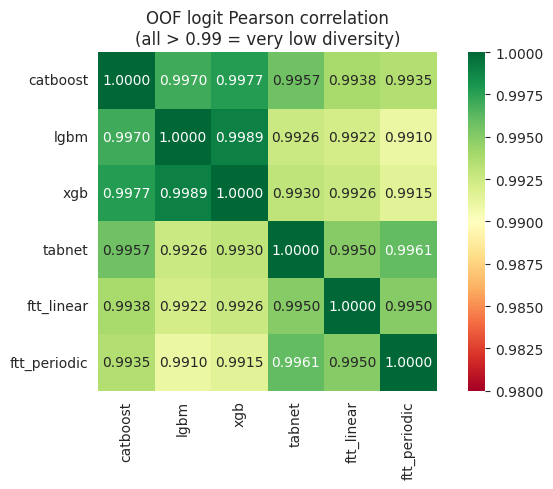

In [4]:
names  = list(base_oofs.keys())
logits = np.column_stack([
    logit(np.clip(base_oofs[n], 1e-6, 1-1e-6)) for n in names
])

corr_df = pd.DataFrame(np.corrcoef(logits.T), index=names, columns=names)
print('Pairwise Pearson correlation of logit(OOF):')
print(corr_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.98, vmax=1.0, ax=ax, square=True)
ax.set_title('OOF logit Pearson correlation\n(all > 0.99 = very low diversity)')
plt.tight_layout()
plt.show()

## Build Meta-Features

In [5]:
# Meta-features: raw OOF probabilities (not logit — CatBoost handles non-linearity)
X_meta_train = np.column_stack([base_oofs[n]  for n in names]).astype(np.float32)
X_meta_test  = np.column_stack([base_tests[n] for n in names]).astype(np.float32)

print(f'Meta-feature matrix: train={X_meta_train.shape}  test={X_meta_test.shape}')
print(f'Features: {names}')

Meta-feature matrix: train=(630000, 6)  test=(270000, 6)
Features: ['catboost', 'lgbm', 'xgb', 'tabnet', 'ftt_linear', 'ftt_periodic']


## Variant 1: CatBoost Meta on OOF Features Only

In [6]:
def catboost_meta_cv(
    X_train, X_test, y,
    label,
    depth=3,
    iterations=500,
    lr=0.05,
    n_splits=5,
    random_state=42,
):
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof  = np.zeros(len(y))
    test_preds = np.zeros((n_splits, len(X_test)))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
        model = CatBoostClassifier(
            iterations       = iterations,
            depth            = depth,
            learning_rate    = lr,
            loss_function    = 'Logloss',
            eval_metric      = 'AUC',
            early_stopping_rounds = 50,
            verbose          = 0,
            random_seed      = random_state,
            task_type        = 'GPU',
        )
        model.fit(
            X_train[tr_idx], y[tr_idx],
            eval_set=(X_train[val_idx], y[val_idx]),
        )
        oof[val_idx]      = model.predict_proba(X_train[val_idx])[:, 1]
        test_preds[fold]  = model.predict_proba(X_test)[:, 1]
        fold_auc = roc_auc_score(y[val_idx], oof[val_idx])
        print(f'  [{label}] Fold {fold+1}  AUC={fold_auc:.5f}  '
              f'best_iter={model.best_iteration_}')

    cv_auc     = roc_auc_score(y, oof)
    test_final = test_preds.mean(axis=0)
    print(f'\n  [{label}] OOF AUC = {cv_auc:.5f}  (baseline {BASELINE_AUC:.5f}, '
          f'delta={cv_auc - BASELINE_AUC:+.5f})')
    return oof, test_final, cv_auc


print('=== Variant 1: CatBoost meta on OOF probs only ===')
oof_v1, test_v1, auc_v1 = catboost_meta_cv(
    X_meta_train, X_meta_test, y,
    label='meta_oof_only', depth=3, iterations=500, lr=0.05,
)

=== Variant 1: CatBoost meta on OOF probs only ===


Default metric period is 5 because AUC is/are not implemented for GPU


  [meta_oof_only] Fold 1  AUC=0.95566  best_iter=497


Default metric period is 5 because AUC is/are not implemented for GPU


  [meta_oof_only] Fold 2  AUC=0.95469  best_iter=302


...

  [meta_oof_only] Fold 3  AUC=0.95548  best_iter=251


Default metric period is 5 because AUC is/are not implemented for GPU


  [meta_oof_only] Fold 4  AUC=0.95504  best_iter=495


Default metric period is 5 because AUC is/are not implemented for GPU


  [meta_oof_only] Fold 5  AUC=0.95583  best_iter=405

  [meta_oof_only] OOF AUC = 0.95532  (baseline 0.95540, delta=-0.00008)


## Variant 2: CatBoost Meta on OOF + Raw Features

Adds original 14 features so the meta-model can learn  
"for patient with X profile, trust model Y more".

In [8]:

# Build extended meta-feature DataFrame:
#   - OOF probs (float) as meta_catboost, meta_lgbm, ...
#   - Raw numerical features (float)
#   - Raw categorical features (original string values — CatBoost handles natively)

meta_cols = {f'meta_{n}': base_oofs[n]  for n in names}
meta_test_cols = {f'meta_{n}': base_tests[n] for n in names}

df_train_ext = pd.DataFrame(meta_cols)
df_test_ext  = pd.DataFrame(meta_test_cols)

for col in NUM_FEATURES:
    df_train_ext[col] = train[col].values
    df_test_ext[col]  = test[col].values

for col in CAT_FEATURES:
    df_train_ext[col] = train[col].values.astype(str)
    df_test_ext[col]  = test[col].values.astype(str)

cat_col_names = CAT_FEATURES  # pass column names, not indices

print(f'Extended DataFrame: train={df_train_ext.shape}  test={df_test_ext.shape}')
print(f'Dtypes sample: {df_train_ext.dtypes.value_counts().to_dict()}')

print('\n=== Variant 2: CatBoost meta on OOF + raw features ===')

skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_v2  = np.zeros(len(y))
test_v2 = np.zeros((5, len(test)))

for fold, (tr_idx, val_idx) in enumerate(skf.split(df_train_ext, y)):
    model = CatBoostClassifier(
        iterations            = 500,
        depth                 = 3,
        learning_rate         = 0.05,
        loss_function         = 'Logloss',
        eval_metric           = 'AUC',
        early_stopping_rounds = 50,
        cat_features          = cat_col_names,
        verbose               = 0,
        random_seed           = 42,
        task_type             = 'GPU',
    )
    model.fit(
        df_train_ext.iloc[tr_idx], y[tr_idx],
        eval_set=(df_train_ext.iloc[val_idx], y[val_idx]),
    )
    oof_v2[val_idx] = model.predict_proba(df_train_ext.iloc[val_idx])[:, 1]
    test_v2[fold]   = model.predict_proba(df_test_ext)[:, 1]
    fold_auc = roc_auc_score(y[val_idx], oof_v2[val_idx])
    print(f'  [meta_extended] Fold {fold+1}  AUC={fold_auc:.5f}  '
          f'best_iter={model.best_iteration_}')

auc_v2  = roc_auc_score(y, oof_v2)
test_v2 = test_v2.mean(axis=0)
print(f'\n  [meta_extended] OOF AUC = {auc_v2:.5f}  '
      f'(baseline {BASELINE_AUC:.5f}, delta={auc_v2 - BASELINE_AUC:+.5f})')


Extended DataFrame: train=(630000, 19)  test=(270000, 19)
Dtypes sample: {dtype('O'): 8, dtype('float64'): 7, dtype('int64'): 4}

=== Variant 2: CatBoost meta on OOF + raw features ===


Default metric period is 5 because AUC is/are not implemented for GPU


  [meta_extended] Fold 1  AUC=0.95559  best_iter=324


Default metric period is 5 because AUC is/are not implemented for GPU


  [meta_extended] Fold 2  AUC=0.95464  best_iter=90


...

  [meta_extended] Fold 3  AUC=0.95542  best_iter=116


Default metric period is 5 because AUC is/are not implemented for GPU


  [meta_extended] Fold 4  AUC=0.95498  best_iter=254


Default metric period is 5 because AUC is/are not implemented for GPU


  [meta_extended] Fold 5  AUC=0.95578  best_iter=214

  [meta_extended] OOF AUC = 0.95523  (baseline 0.95540, delta=-0.00017)


## Compare Variants

In [9]:
print('=== Summary ===')
print(f'CatBoost baseline:          {BASELINE_AUC:.5f}')
print(f'V1 — meta OOF only:         {auc_v1:.5f}  ({auc_v1 - BASELINE_AUC:+.5f})')
print(f'V2 — meta OOF + raw feats:  {auc_v2:.5f}  ({auc_v2 - BASELINE_AUC:+.5f})')

=== Summary ===
CatBoost baseline:          0.95540
V1 — meta OOF only:         0.95532  (-0.00008)
V2 — meta OOF + raw feats:  0.95523  (-0.00017)


## Submit Best Variant (if better than baseline)

In [10]:
ON_KAGGLE = Path('/kaggle/working').exists()

results = [
    ('meta_cat_oof_only',     auc_v1, test_v1),
    ('meta_cat_oof_raw_feats', auc_v2, test_v2),
]

for label, cv_auc, test_preds in results:
    print(f'\n--- {label}  CV={cv_auc:.5f} ---')
    fname = f'submissions/{label}.csv'
    sub   = ss.copy()
    sub['Heart Disease'] = test_preds
    sub.to_csv(fname, index=False)

    desc = f'{label} | cv_auc={cv_auc:.4f}'

    if ON_KAGGLE:
        print(f'Submit: kaggle competitions submit -c playground-series-s6e2 -f {fname} -m "{desc}"')
    else:
        r = subprocess.run(
            ['kaggle', 'competitions', 'submit', '-c', 'playground-series-s6e2',
             '-f', fname, '-m', desc],
            capture_output=True, text=True
        )
        status = 'submitted' if 'successfully' in r.stdout.lower() else r.stdout.strip()[:120]
        print(f'  {status}')
        print(f'  desc: {desc}')


--- meta_cat_oof_only  CV=0.95532 ---
  submitted
  desc: meta_cat_oof_only | cv_auc=0.9553

--- meta_cat_oof_raw_feats  CV=0.95523 ---
  submitted
  desc: meta_cat_oof_raw_feats | cv_auc=0.9552


## Conclusion

In [11]:
best_auc   = max(auc_v1, auc_v2)
best_label = 'V1 (OOF only)' if auc_v1 >= auc_v2 else 'V2 (OOF + raw)'

print('=== Conclusion ===')
print(f'Best non-linear stacking: {best_label}  AUC={best_auc:.5f}')
print(f'vs CatBoost baseline:     {BASELINE_AUC:.5f}  (delta={best_auc - BASELINE_AUC:+.5f})')
print()
if best_auc > BASELINE_AUC + 0.0001:
    print('Non-linear stacking improved over baseline. Consider for final submission.')
elif best_auc > BASELINE_AUC:
    print('Marginal CV gain — within public LB noise (~0.0003). Submitted as data point.')
else:
    print('No improvement. Pairwise OOF correlation ~0.99+ leaves no orthogonal signal.')
    print('Expected: even non-linear meta cannot recover signal from near-duplicate predictions.')

=== Conclusion ===
Best non-linear stacking: V1 (OOF only)  AUC=0.95532
vs CatBoost baseline:     0.95540  (delta=-0.00008)

No improvement. Pairwise OOF correlation ~0.99+ leaves no orthogonal signal.
Expected: even non-linear meta cannot recover signal from near-duplicate predictions.
